# RPS tracking

This notebook shows the full RPS-tracking loop: pull a recording span, examine it, run a neural predictor from the zoo, and run the blind DSP tracking ladder on the same audio. Each step is one or two calls into the library (`plots.explore`, `plots.dwym`, `zoo`, `tracking`).

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
for p in (ROOT, ROOT / "src"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import numpy as np
import tdseries as td
import matplotlib.pyplot as plt

from plots import dwym, explore

## 1 · Datasets

`explore.datasets()` lists every published dataset pinned in `dload.lock`. Pass `sizes=True` for sample counts (fetches manifests).

In [2]:
explore.datasets()

,name,version
0,AVQ,50dd53d1a6c0
1,AVQ-egonoise,b43b374b007a
2,AVQ-egonoise-vkrps,266f5241bfb0
3,AVQ-raw,0e17e52b16c3
4,AeroSonicDB,0d5543419ea5
5,Blackbird-frames,c08a5c8d8663
6,DN-LM-train,4576c1679b3b
7,DN-LM-valid,f6e7038600b9
8,DREGON,db39bcf762d0
9,DREGON-LM-V2-train,8a81bf7b7b5d


## 2 · Pull a recording span

The data cells stream from R2. This guard fails early, with a clear message, when credentials are missing.

In [3]:
import os

import data_processing.streams  # noqa: F401 — loads the .env credentials

if not os.environ.get("AWS_ACCESS_KEY_ID"):
    raise RuntimeError(
        "No R2 credentials. The cells below stream dload datasets. "
        "Fill .env at the repo root (see docs/data-and-artifacts.md), then rerun."
    )

In [4]:
import torch, torch.nn.functional as F
import zoo
from experiments import rps_bench as rb
from pathlib import Path
from plots.rps_prediction.full_sequence import plot_full_sequence

def plot_overlay(o):
    plot_full_sequence(
        audio=np.asarray(o["audio"].data).squeeze(),
        rps_gt=np.asarray(o["rps"].data),          # (4, T_gt)
        rps_pred=np.asarray(o["rps_pred"].data),   # (4, T), already PIT-aligned; the plot re-aligns, harmless
        sr=16000,
        title=f"{o['meta']['flight']} mic {o['meta']['channel']}  MAE {o['meta']['mae']:.2f}",
        figsize=(15, 8)
    )

## 3 · The synthetic-only predictors, two generations, on real frames

`zoo.load(exp, ckpt=)` returns any trained experiment as one Frame → Frame callable. This section puts the **synthetic-only** arms of both noise-model generations on the same real validation frames and asks the campaign's open question: the hand-written stochastic family (`rig_*`, best real MAE **5.72** easy / **5.37** hard) transfers BETTER than the fitted v2 family that replaced it (`nv2_*`, **7.94** / **7.06** on the regressor, **6.46** / **6.47** on the salience trunk) — where does that show up in a single clip?

**Which checkpoint.** Every arm below ran the unified validation panel (`conf/validation/rps_unified.yaml`), whose control score is `overall_macro` — half synthetic. Its `best.ckpt` is therefore a byte-identical alias of `best_overall_macro.ckpt`, and for `rig_easy_scv2_unified` that round scores `val/real_overall` **7.16**, not the headline 5.72. The file the headline numbers belong to is `best_real_overall.ckpt` (round 57 easy / 124 hard, raw 6.09 / 5.41; the quoted 5.72 / 5.37 is the best raw value of the run, which no checkpoint corresponds to — see `docs/experiments/noise-v2-transfer.md`). So **all eight unified arms are read from `best_real_overall`**, which is the only apples-to-apples choice. `hppnet_l2_r2_s0` predates the panel and has one `best.ckpt`.

**Which arms.** Legacy synthetic-only: `rig_easy_scv2_unified`, `rig_hard_scv2_unified` — the 5.72 / 5.37 runs — plus `rig_easy_hppnet_l2_unified`, the one salience arm of that generation (there is **no** `rig_hard_hppnet_l2_unified`: it was never configured and no checkpoint exists on R2, so the legacy salience family is a single arm). v2 synthetic-only: `nv2_{easy,hard}_{scv2,hppnet_l2}`. References trained on real audio: `real_r4_scv2_unified` (2.99) and `hppnet_l2_r2_s0` (2.27).

In [5]:
# The model list — one dict, edit it. label -> (experiment, checkpoint).
MODELS = {
    "legacy easy · SCv2":      ("rig_easy_scv2_unified",      "best_real_overall"),
    "legacy hard · SCv2":      ("rig_hard_scv2_unified",      "best_real_overall"),
    "legacy easy · HPPNet-L2": ("rig_easy_hppnet_l2_unified", "best_real_overall"),
    "v2 easy · SCv2":          ("nv2_easy_scv2",              "best_real_overall"),
    "v2 hard · SCv2":          ("nv2_hard_scv2",              "best_real_overall"),
    "v2 easy · HPPNet-L2":     ("nv2_easy_hppnet_l2",         "best_real_overall"),
    "v2 hard · HPPNet-L2":     ("nv2_hard_hppnet_l2",         "best_real_overall"),
    "real ref · SCv2":         ("real_r4_scv2_unified",       "best_real_overall"),
    "real ref · HPPNet-L2":    ("hppnet_l2_r2_s0",            "best"),
}

# every checkpoint exists on R2 — this fails loudly if one is missing
for _label, (_exp, _ckpt) in MODELS.items():
    _files = {r["experiment"]: r["files"] for r in zoo.checkpoints(max_age_s=10**9)}.get(_exp, [])
    assert f"{_ckpt}.ckpt" in _files, f"{_label}: {_exp}/{_ckpt}.ckpt not on R2 ({sorted(_files)})"
print(f"{len(MODELS)} models, all checkpoints present")

9 models, all checkpoints present


### Which frame?

`rb.PARTS["real"]` is the frozen real validation split (`conf/data/m3cur_s2.yaml` valid block, `dload:DREGON-LM-V4-michaels-valid-full`): 37 eight-second clips × 8 microphones = 296 frames. `rb.frames_table` says what each one is — the airframe (DREGON room1 vs Michael's FLY124), the mic, what the label does, and the flight regime under the campaign's stated thresholds (`rb.REGIME_THRESHOLDS`: ramp when |d mean speed/dt| ≥ 20 rev/s², else zero / standby / cruise by level — the split `scripts/_regime_decomp.py` reports its per-regime tables on).

In [6]:
frames = rb.frames_table("real")
frames.groupby(["dataset", "recording", "regime"]).size()

dataset   recording                         regime 
dregon    free-flight_nosource_room1        cruise     56
                                            zero        8
          free-flight_speech-low_room1      cruise     48
                                            zero        8
          free-flight_whitenoise-low_room1  cruise     40
                                            zero       16
michaels  michaels_FLY124                   cruise     72
                                            standby    32
                                            zero       16
dtype: int64

In [7]:
# one clean-cruise frame per airframe, picked from the table, not typed by hand
_cruise = frames[(frames.mic == 0) & (frames.regime == "cruise") & (frames.regime_share == 1.0)]
CRUISE_FRAME = int(_cruise[_cruise.dataset == "michaels"].frame.iloc[0])
DREGON_FRAME = int(_cruise[_cruise.dataset == "dregon"].frame.iloc[0])
print(f"CRUISE_FRAME = {CRUISE_FRAME}   DREGON_FRAME = {DREGON_FRAME}")
frames.loc[[CRUISE_FRAME, DREGON_FRAME]]

CRUISE_FRAME = 216   DREGON_FRAME = 16


,frame,clip,recording,dataset,mic,mean_speed,speed_range,regime,regime_share
216,216,sample_00027,michaels_FLY124,michaels,0,80.374167,10.033333,cruise,1.0
16,16,sample_00002,free-flight_speech-low_room1,dregon,0,80.441599,4.178562,cruise,1.0


### Every model on one frame

`rb.compare` takes the `MODELS` dict, runs each checkpoint live on the CPU and PIT-aligns it to the label; `rb.show` draws the spectrogram, the label and one row per model on one time axis. Predictions are memoised per (experiment, checkpoint, readout, part, frame) under `.cache/rps_bench/preds/`, so changing one frame does not re-run the models you already have.

**Which readout.** The four HPPNet-L2 arms emit a salience map, not speeds, so the number depends on how that map is decoded. `readout="deployed"` (the default) calls the model's own `decode_logits` — per-layer CRF for these four-layer ports — exactly as `training/validation.py::_salience_readout` and `scripts/_regime_decomp.py` call it, so the rows below are the decoder the campaign's checkpoint selection and per-regime tables were measured with. `readout="peak"` is the peak + parabola readout of `rb.Readout`, which is what the `rps_mae` monitor metric and the `results/rps_dump/` arrays hold; it is kept for dump compatibility. The two agree to 0.14 rev/s of clip MAE on these clean-cruise frames (they differ by up to 50 rev/s on individual frames, where the CRF's transition band refuses a jump the per-frame peak takes).

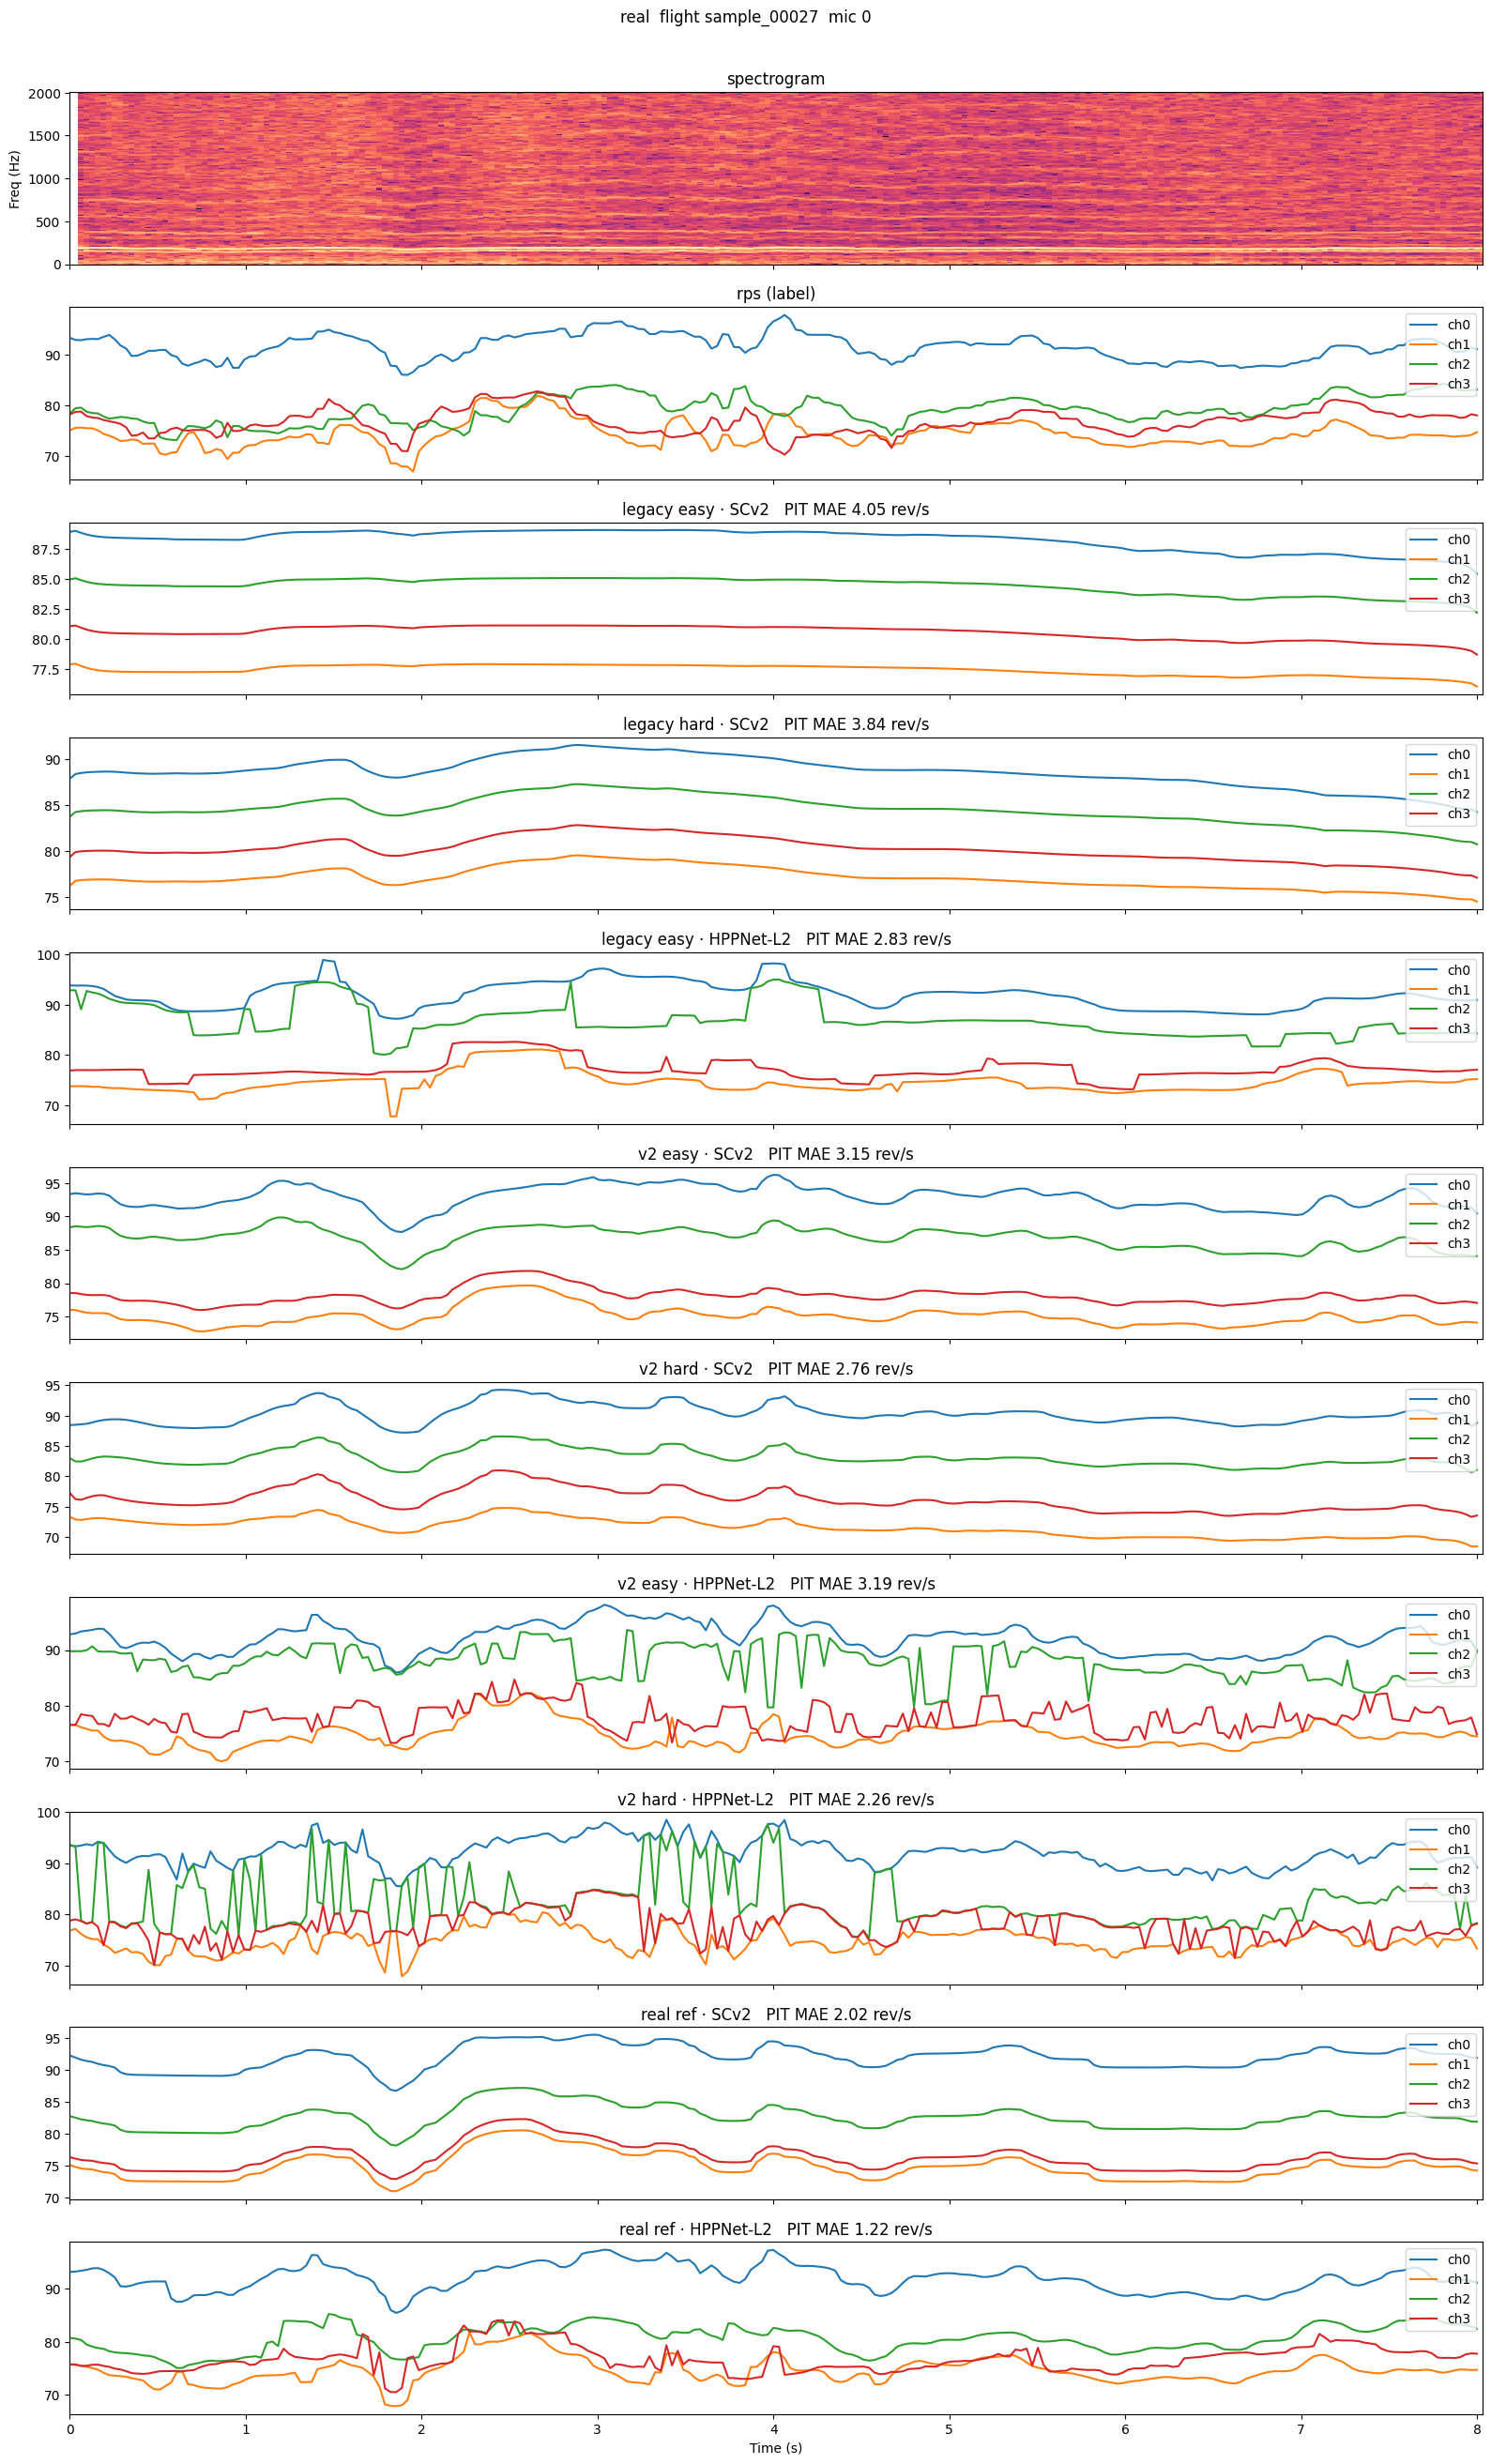

In [8]:
rb.show(rb.compare(MODELS, "real", CRUISE_FRAME, source="live", readout="deployed"), fmax=2000);

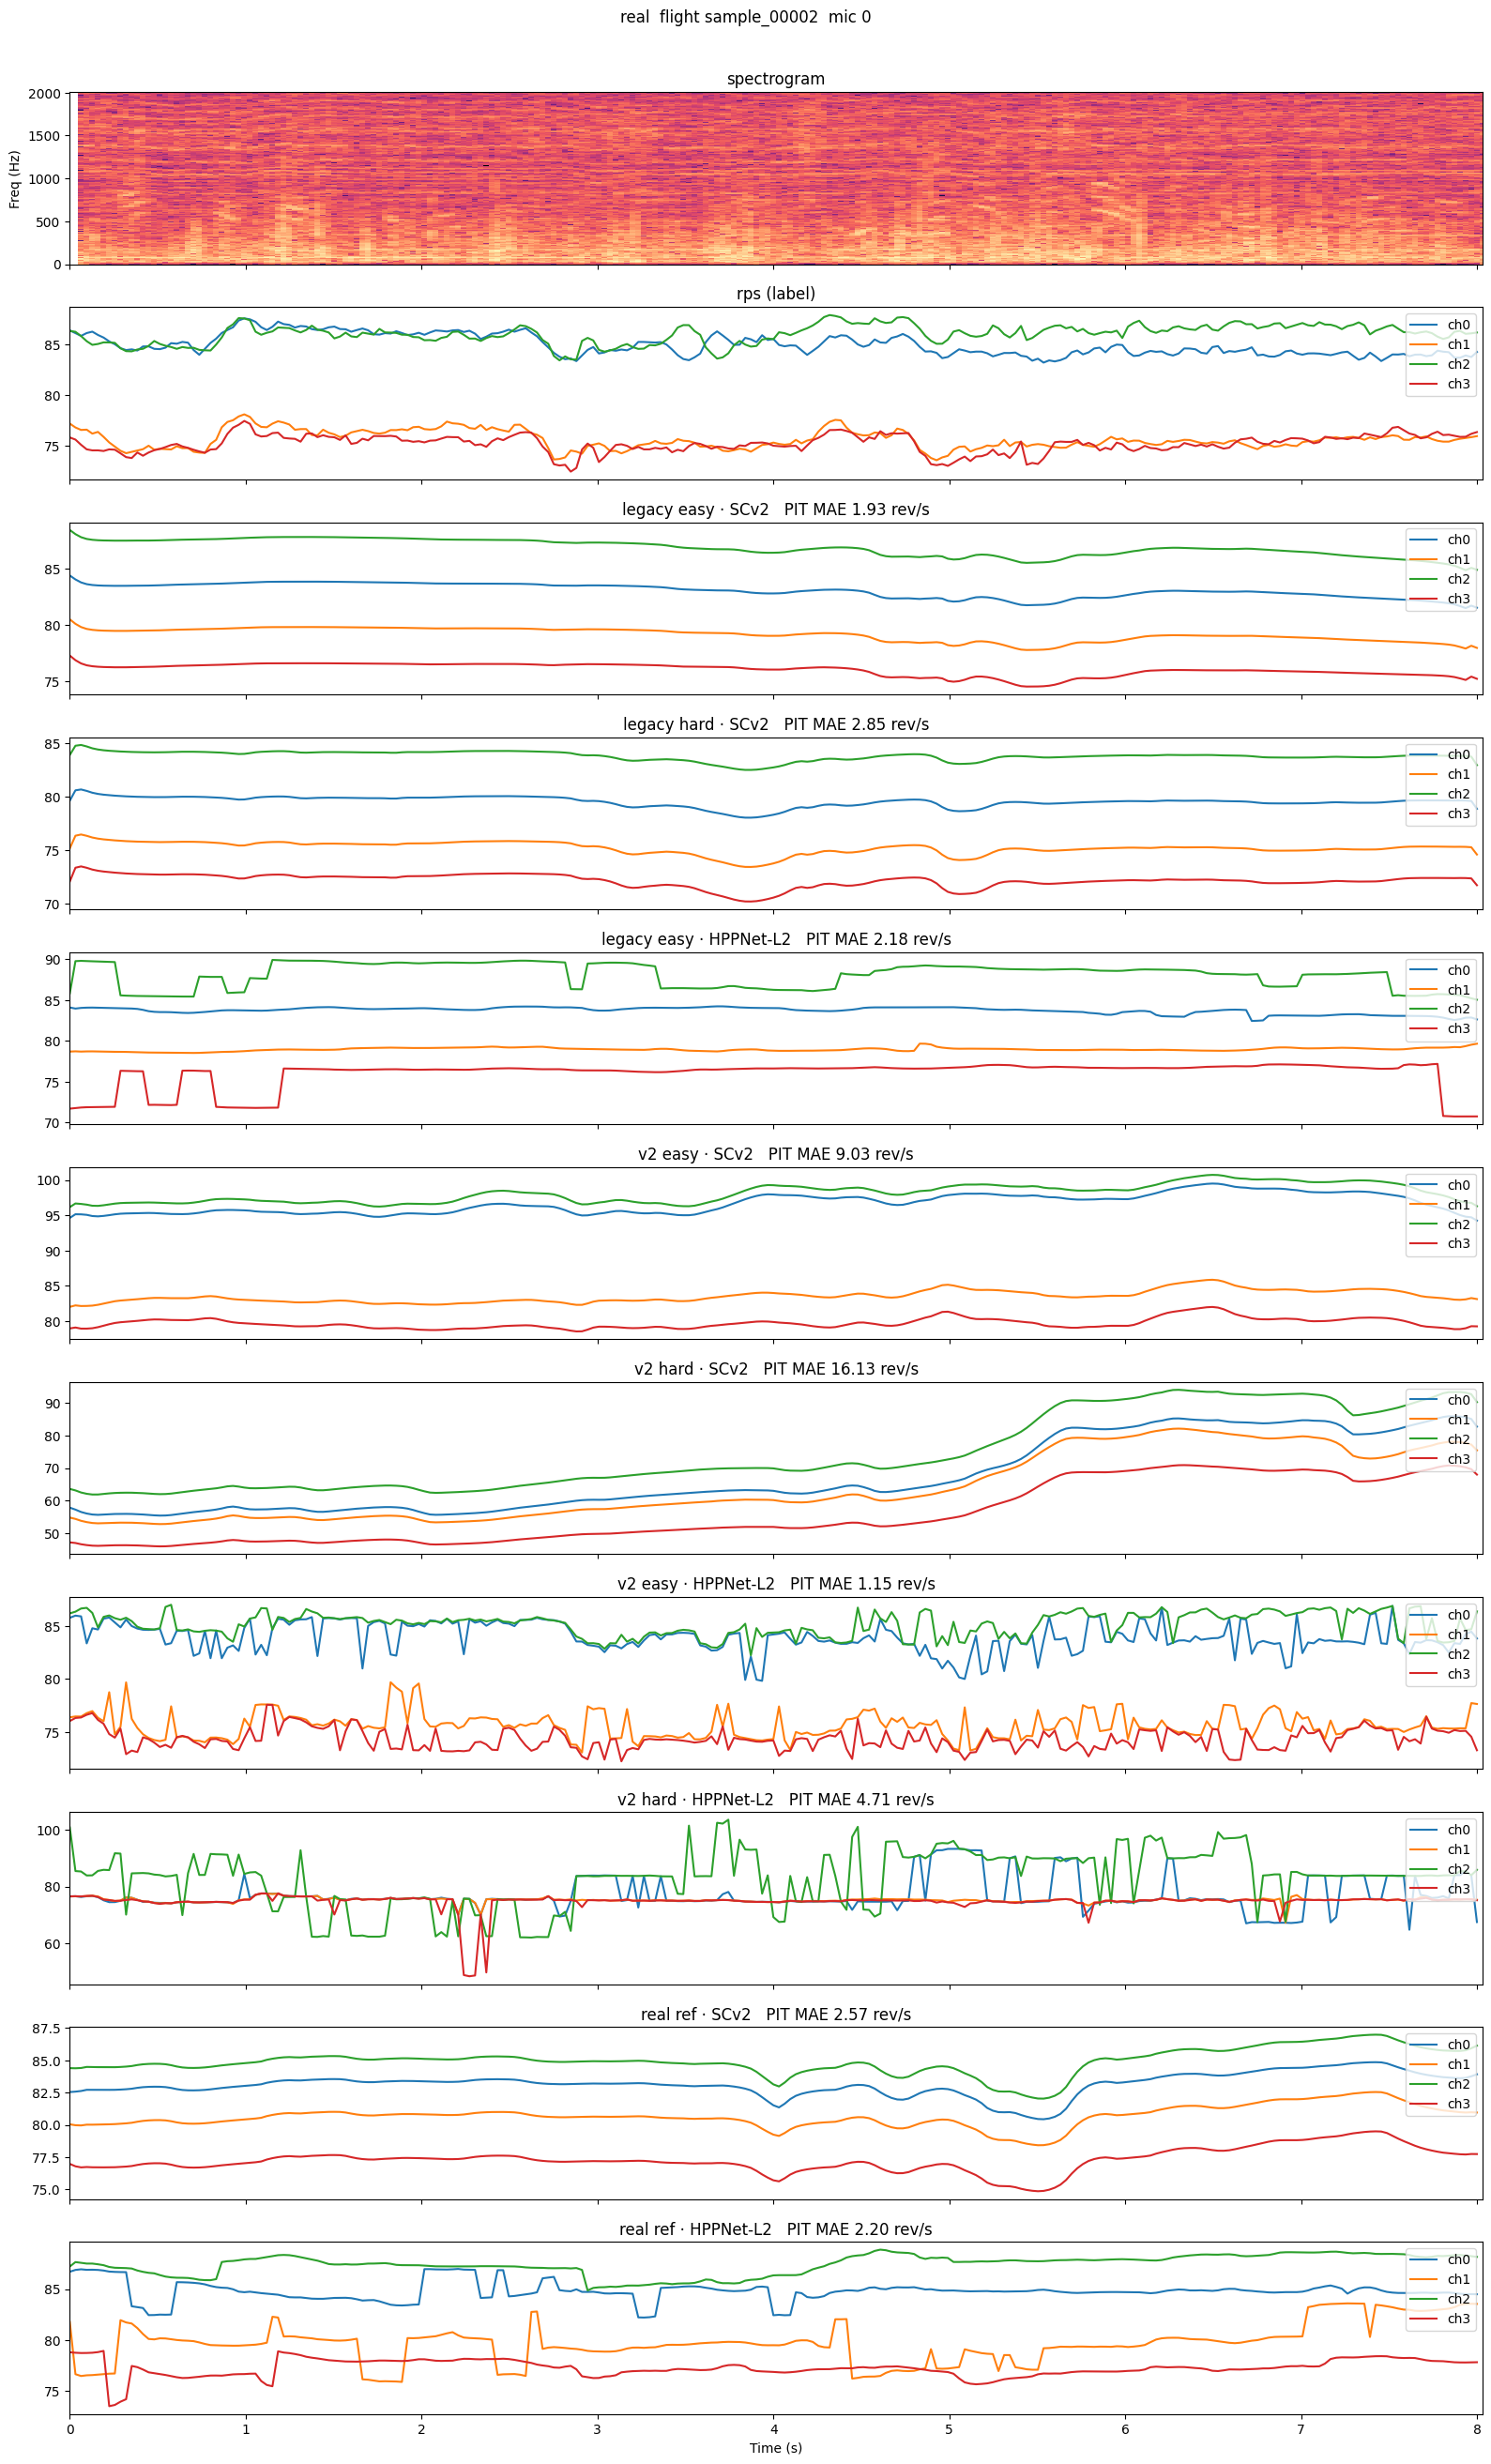

In [9]:
rb.show(rb.compare(MODELS, "real", DREGON_FRAME, source="live", readout="deployed"), fmax=2000);

### The numbers behind those rows

PIT MAE in rev/s under the **deployed** readout (`decode_logits` for the salience arms, `rps_pred` for the regressors); rows = models, columns = frames. Pass any list of frame indices.

In [10]:
rb.mae_table(MODELS, "real", [CRUISE_FRAME, DREGON_FRAME], source="live", readout="deployed").round(2)

,michaels/sample_00027 mic 0,dregon/sample_00002 mic 0,mean
legacy easy · SCv2,4.05,1.93,2.99
legacy hard · SCv2,3.84,2.85,3.34
legacy easy · HPPNet-L2,2.83,2.18,2.50
v2 easy · SCv2,3.15,9.03,6.09
v2 hard · SCv2,2.76,16.13,9.45
v2 easy · HPPNet-L2,3.19,1.15,2.17
v2 hard · HPPNet-L2,2.26,4.71,3.49
real ref · SCv2,2.02,2.57,2.29
real ref · HPPNet-L2,1.22,2.20,1.71


### One model, full detail

`zoo.load` on its own gives the `FrameModel`; `rb.overlay` runs it on one frame and `plot_overlay` (defined above, `plots.rps_prediction.full_sequence`) draws the per-rotor tracks large enough to read the rotor spread — the quantity the transfer campaign found collapsed on the synthetic arms.

In [11]:
hppnet_l2 = zoo.load("hppnet_l2_r2_s0")
hppnet_l2

FrameModel(task='salience_rps', experiment='hppnet_l2_r2_s0', model=HPPNetOrig, device=cpu)

/home/flyingleafe/Research/PhD/projects/harmonic-noise-suppression/src/plots/rps_prediction/full_sequence.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


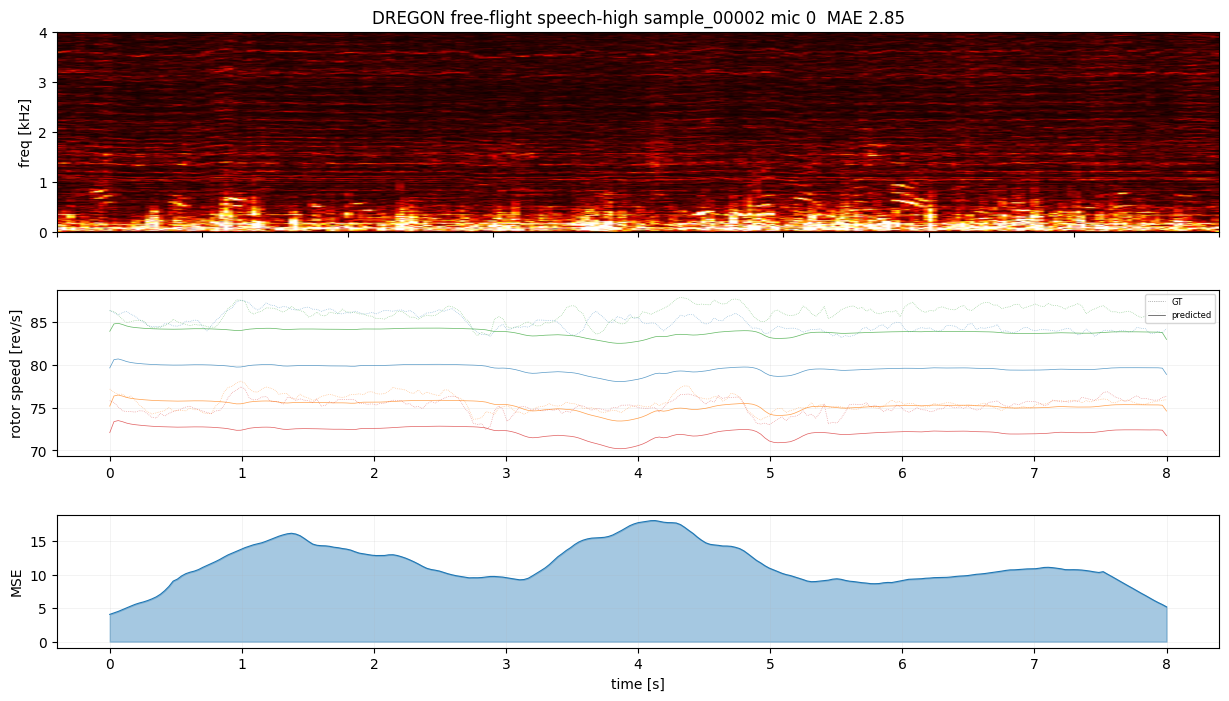

In [12]:
_exp, _ckpt = MODELS["legacy hard · SCv2"]
plot_overlay(rb.overlay(_exp, "real", DREGON_FRAME, source="live", ckpt=_ckpt, readout="deployed"))

/home/flyingleafe/Research/PhD/projects/harmonic-noise-suppression/src/plots/rps_prediction/full_sequence.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


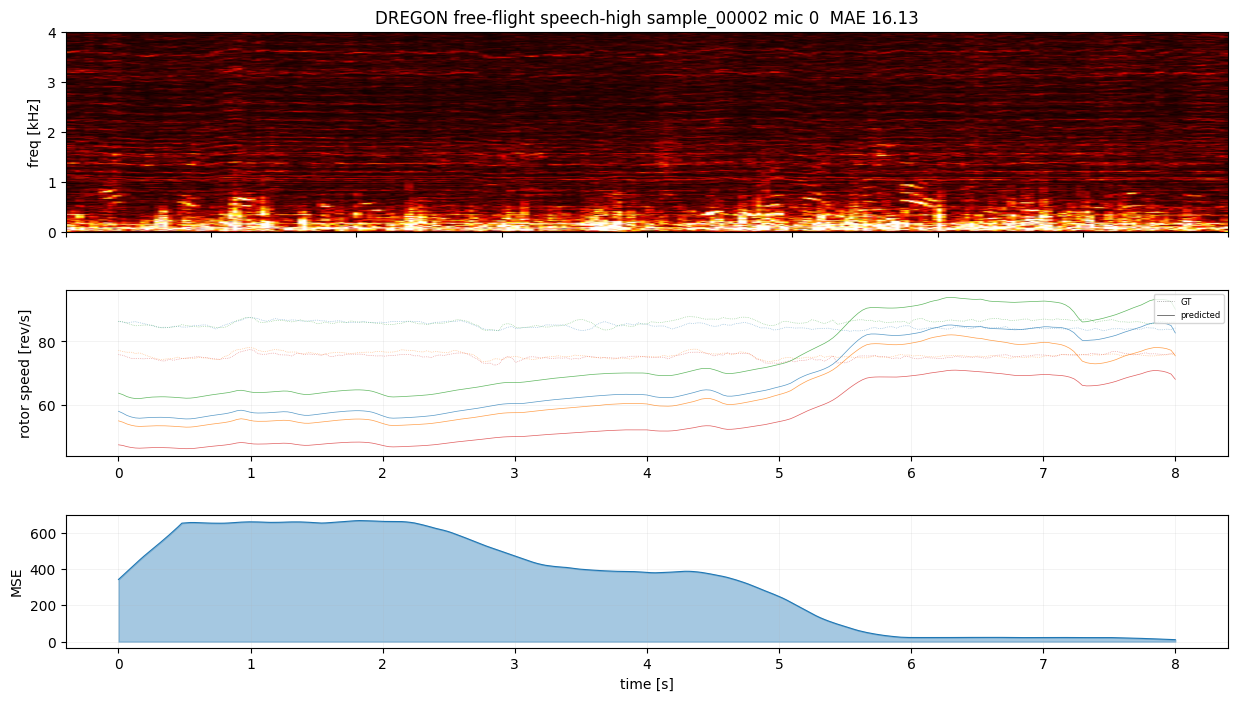

In [13]:
_exp, _ckpt = MODELS["v2 hard · SCv2"]
plot_overlay(rb.overlay(_exp, "real", DREGON_FRAME, source="live", ckpt=_ckpt, readout="deployed"))

## 4 · The blind DSP tracking ladder

Tracking stages are `td.Frame → td.Frame` callables (`tracking.stages`). `blind_seed_stage` finds the base speeds; the guarded VK stage captures and refines the trajectories. For the full calibrated annotation ladder, use `tracking.vit2dsp_stage`.

In [ ]:
import tracking as trk

tf = td.Frame({"audio": audio16, "rps_meas": clip["rps"], "meta": td.Frame({})})
ladder = trk.pipeline(trk.blind_seed_stage(4), trk.guarded(trk.vk_stage(trk.CAPTURE_CFG)))
tracked = ladder(tf)  # roughly a minute on CPU for 8 s of audio

Overlay the tracked trajectories on the telemetry the same way.

In [ ]:
overlay = td.Frame({"audio": audio16, "rps": clip["rps"], "rps_pred": tracked["rps"]})
dwym(overlay, fmax=800)

## 5 · The tracking log

Every stage appends one diagnostics dict to `meta["tracking"]`.

In [ ]:
for entry in tracked["meta"]["tracking"]:
    info = {k: v for k, v in entry.items() if k != "stage"}
    print(f"{entry['stage']:12s} {info}")

## 6 · Any predictor on the benchmark parts, side by side

Three parts, the same for every model (`experiments.rps_bench.PARTS`): the salv2 static comb (`comb`), the salv2 stochastic comb (`stoch`) and the real full-envelope split (`real`), plus the speech twins `comb_speech` / `stoch_speech`. A frame is one microphone of an 8 s clip: frame `i` of a synthetic part is flight `i // 8`, mic `i % 8`.

Predictions come from the dump `results/rps_dump/` (27 checkpoints, `scripts/rps_dump.py`) when it holds the experiment, else from the checkpoint through `zoo.load` on the CPU (`source="live"` forces that; any `zoo` experiment works). A part is synthesized once and pickled under `.cache/rps_bench/`; `real` needs R2 credentials. `rb.worst` reads `results/rps_profile/frames.csv` (`scripts/rps_error_profile.py`), so the failures are one call away.

In [ ]:
from experiments import rps_bench as rb

rb.experiments()  # what the dump holds; any other zoo experiment runs live

In [ ]:
rb.worst("real", "hppnet_r4_l4")  # the frames worth a look: index, flight, mic, PIT MAE, error class

In [ ]:
# several models on ONE frame: spectrogram, label, one PIT-aligned row per model
f = rb.compare(["hppnet_r4_l4", "r4hb_scv2", "m3mixv2_unigru128"], "real", 71)
rb.show(f, fmax=2000);

In [ ]:
# ONE model across the parts: dwym takes a {label: overlay} dict and aligns the blocks
dwym({p: rb.overlay("salv2_hppnet_stoch_nomix", p, 8) for p in ("comb", "stoch", "real")}, fmax=2000)

In [ ]:
# a model the dump does not hold (or a fresh checkpoint): the same call, run live on the CPU
dwym(rb.overlay("salv2_hppnet_comb_nomix", "comb", 19 * 8 + 3, source="live"), fmax=2000)

Next steps: `docs/notebook-primitives-tutorial.md` walks each primitive, `src/tracking/AGENTS.md` documents the stage API, and `notebooks/AGENTS.md` maps the other notebooks.